# TP d’Analyse Fonctionnelle

### Auteures :  
- **Hiba Fahli**  
- **Hiba Hanini**

### Date :  
**5 novembre 2025**


In [ ]:
!pip install numpy matplotlib scipy

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.fft import fft, fftshift, fftfreq

## **Exercice 1 : Calcul approché d'un spectre**

## Question 1. Calcul de $S_N(\lambda)$ en fonction de $F_0$ :
L’objectif est d’exprimer le spectre approché $S_N(\lambda)$ en fonction du vrai spectre continu $F_0$.
### a. Calcul :
On a :

$$
\begin{aligned}
S_N(\lambda)
&= \sum_{n=-N}^{N-1} x_n\, e^{-i 2\pi \lambda n a} \\[4pt]
&= a \sum_{n=-N}^{N-1} e^{i 2 \pi F_0 n a}\, e^{-i 2 \pi \lambda n a} \\[4pt]
&= a \sum_{n=-N}^{N-1} e^{i 2 \pi n a (F_0 - \lambda)} \\[4pt]
&= a \sum_{n=-N}^{N-1} \left( e^{i 2 \pi a (F_0 - \lambda)} \right)^n \\[4pt]
&= a \sum_{n=0}^{2N-1} e^{i 2 \pi a (F_0 - \lambda)(n - N)} \\[4pt]
&= a\, e^{-i 2 \pi a N (F_0 - \lambda)}
   \sum_{n=0}^{2N-1} \left(e^{i 2 \pi a (F_0 - \lambda)}\right)^n \\[6pt]
&= a\, e^{-i 2 \pi a N (F_0 - \lambda)}
   \frac{1 - e^{i 2 \pi a (F_0 - \lambda) 2N}}
        {1 - e^{i 2 \pi a (F_0 - \lambda)}} \\[6pt]
&= a\, e^{-i 2 \pi a N (F_0 - \lambda)}
   \frac{
      e^{i 2 \pi a N (F_0 - \lambda)} (-2i)\sin(2\pi a N (F_0 - \lambda))
   }{
      e^{i \pi a (F_0 - \lambda)} (-2i)\sin(\pi a (F_0 - \lambda))
   } \\[6pt]
&= a\, e^{-i \pi a (F_0 - \lambda)}
   \frac{
      \sin\!\left(2\pi a N (F_0 - \lambda)\right)
   }{
      \sin\!\left(\pi a (F_0 - \lambda)\right)
   }.
\end{aligned}
$$

Donc :

$$
\boxed{
S_N(\lambda)
= a\, e^{-i \pi a (F_0 - \lambda)}
  \frac{\sin\!\left(2\pi a N (F_0 - \lambda)\right)}
       {\sin\!\left(\pi a (F_0 - \lambda)\right)}
}
$$
### b. Relation par convolution :


On part de :

$$
S_N(\lambda)
= \sum_{n=-N}^{N-1} x_n\, e^{-i 2\pi \lambda n a},
\qquad x_n = f(na).
$$

Avec :

$$
f(na)
= \int_{-\infty}^{\infty} \hat f^{\,0}(\nu)\, e^{i 2\pi \nu n a}\, d\nu.
$$

On obtient :

$$
\begin{aligned}
S_N(\lambda)
&= \sum_{n=-N}^{N-1}
   \left(
      \int_{-\infty}^{\infty}
      \hat f^{\,0}(\nu)\, e^{i 2\pi \nu n a}\, d\nu
   \right)
   e^{-i 2\pi \lambda n a} \\[6pt]
&= a \int_{-\infty}^{\infty}
     \hat f^{\,0}(\nu)
     \left(
         \sum_{n=-N}^{N-1}
         e^{-i 2\pi n a (\lambda - \nu)}
     \right)
     d\nu \\[6pt]
&= a \int_{-\infty}^{\infty}
     \hat f^{\,0}(\nu)\, K(\nu - \lambda)\, d\nu.
\end{aligned}
$$

Avec :

$$
K(\xi)
= \sum_{n=-N}^{N-1} e^{-i 2\pi a n \xi}
= e^{-i\pi a \xi}
  \frac{\sin(\pi T_0 \xi)}{\sin(\pi a \xi)},
\qquad T_0 = 2Na.
$$

Donc :

$$
\boxed{
S_N(\lambda)
= (\hat f^{\,0} * K)(\lambda)
}
$$

### c. Décomposition en terme principal et erreur d’aliasing :


**Effet 1 : échantillonnage**

$$
\hat f^{\,s}(\lambda)
= \frac{1}{a}
  \sum_{m=-\infty}^{\infty}
  \hat f^{\,0}(\lambda - m/a).
$$

**Effet 2 : fenêtre rectangulaire**

$$
S_N(\lambda)
= \hat f^{\,s}(\lambda) * w^{\wedge}(\lambda),
\qquad w^{\wedge}(\lambda) = K(\lambda).
$$

### Expression complète :

$$
S_N(\lambda)
= \sum_{m=-\infty}^{\infty}
  \left(
     \hat f^{\,0}(\lambda - m/a)
     * w^{\wedge}(\lambda)
  \right).
$$

En isolant le terme utile :

$$
S_N(\lambda)
=
\underbrace{
\hat f^{\,0}(\lambda) * w^{\wedge}(\lambda)
}_{\text{Terme principal (lissage / fuite spectrale)}}
+
\underbrace{
\sum_{m\neq 0}
\left(
  \hat f^{\,0}(\lambda - m/a) * w^{\wedge}(\lambda)
\right)
}_{\text{Erreur d'aliasing}}.
$$

## Conclusion pour la question 1 :

Le spectre approché $S_N(\lambda)$ contient deux contributions :

1. **Le terme principal (lissage)**  
   Convolution entre le vrai spectre et la transformée de la fenêtre :

   $$
   \hat f^{\,0}(\lambda) * w^{\wedge}(\lambda).
   $$

2. **L’erreur d’aliasing**  
   Due à la périodisation du spectre :

   $$
   \sum_{m\neq 0} \hat f^{\,0}(\lambda - m/a) * w^{\wedge}(\lambda).
   $$

3. $S_N(\lambda)$ en fonction de $F_0$**

$$
S_N(\lambda) = a \cdot e^{-i \pi a (F_0 - \lambda)} \frac{\sin(2 \pi a N (F_0 - \lambda))}{\sin(\pi a (F_0 - \lambda))}
$$

## Question 2. Explication du calcul de $S_N(\lambda)$ par la TFD :

La formule (1) du spectre approché $S_N(\lambda)$ s'apparente à une **Transformée de Fourier Discrète (TFD)** lorsqu'elle est évaluée aux fréquences discrètes $\lambda_k$.

### Discrétisation de la Fréquence

La TFD opère sur des fréquences discrètes $\lambda_k$ qui sont espacées par le pas de fréquence $\Delta \lambda$, déterminé par la durée totale d'observation $T_0$:

* Durée totale d'observation : $T_0 = 2N a$.
* Intervalle de fréquence : $\Delta \lambda = \frac{1}{T_0} = \frac{1}{2N a}$.
* Fréquences évaluées : $\lambda_k = k \Delta \lambda = \frac{k}{2N a}$ pour $k=0, \dots, 2N-1$.

En substituant $\lambda_k$ dans la formule de $S_N(\lambda)$, et en définissant la séquence échantillonnée $x_n = f(n a)$, nous obtenons :

$$
S_N(\lambda_k) = a \sum_{n=-N}^{N-1} x_n e^{-i 2 \pi \frac{k}{2N a} n a} = a \sum_{n=-N}^{N-1} x_n e^{-i 2 \pi \frac{n k}{2N}}
$$
### Mise en Forme TFD et Décalage Circulaire

Le nombre total d'échantillons est $M=2N$. Pour utiliser l'algorithme standard de la TFD (qui somme de $m=0$ à $M-1$), nous effectuons un **décalage circulaire** des indices en posant $m = n + N$ (d'où $n = m - N$).

En remplaçant $n$ par $m-N$ dans l'expression précédente :

$$
S_N(\lambda_k) = a \sum_{m=0}^{2N-1} x_{m-N} e^{-i 2 \pi \frac{(m-N) k}{2N}}
$$

En séparant le terme exponentiel qui ne dépend pas de $m$ :

$$
S_N(\lambda_k) = a \cdot e^{i 2 \pi \frac{N k}{2N}} \sum_{m=0}^{2N-1} x_{m-N} e^{-i 2 \pi \frac{m k}{2N}}
$$

Comme $e^{i 2 \pi \frac{N k}{2N}} = e^{i \pi k} = (-1)^k$, et en définissant $Y_k$ comme la TFD de la séquence décalée $y_m = x_{m-N} = f((m-N)a)$, on obtient :

$$
S_N(\lambda_k) = a \cdot e^{i \pi k} \cdot Y_k
$$

où $Y_k$ est :

$$
Y_k = \sum_{m=0}^{2N-1} y_m e^{-i 2 \pi \frac{m k}{2N}}
$$

### Conclusion pour la Question 2 :

La formule (1), évaluée aux fréquences $\lambda_k$ de la TFD, peut être calculée en utilisant l'algorithme de la **TFD/FFT** sur les échantillons décalés $y_m = f((m-N)a)$, le résultat étant ensuite multiplié par le facteur d'échelle $a \cdot e^{i \pi k}$.

# Question 3. Étude et interprétation du spectre approché

On utilise :
- $N = 16$
- $a = \frac{1}{32}$
- donc $T = 2Na = 1$

On évalue le spectre aux fréquences $\lambda_k = k$ pour $k \in \{-16,\ldots,15\}$.
Le signal échantillonné est $x_n = e^{2i\pi F_0 n a}$.

### Expression analytique de $S_N(\lambda)$ :
La somme s’écrit :
$$
S_N(\lambda)
= a \sum_{n=-N}^{N-1} e^{-2i\pi n a(\lambda - F_0)}.
$$

Elle correspond à un noyau de Dirichlet :
$$
|S_N(\lambda)| =
a \left|
\frac{\sin\left(2\pi N a (\lambda - F_0)\right)}
{\sin\left(\pi a (\lambda - F_0)\right)}
\right|.
$$

### Cas $F_0 = 7$ :

Ici $F_0 = 7$ coïncide exactement avec un bin $\lambda_7 = 7$.

Donc pour $\lambda = 7$,
$$
\lambda_7 - F_0 = 0,
$$
et les $2N$ termes sont en phase. Par limite du noyau de Dirichlet,
$$
|S_N(7)| = a \cdot 2N = \frac{1}{32} \cdot 32 = 1.
$$

Le spectre contient **un seul pic**, sans fuite.

### Cas $F_0 = 6.4$ :

Cette fréquence n'est alignée avec aucun bin entier.  
Les bins les plus proches sont $k = 6$ et $k = 7$.

Pour $k = 6$ :

- $\lambda_6 - F_0 = 6 - 6.4 = -0.4$
- $\pi a (\lambda_6 - F_0) = -0.0125\pi$
- $\sin(2\pi N a(\lambda_6 - F_0)) = \sin(-0.4\pi)$
- $\sin(\pi a(\lambda_6 - F_0)) = \sin(-0.0125\pi)$

En utilisant la formule,
$$
|S_N(6)| \approx 0.757.
$$

On observe ensuite une décroissance autour de ce bin selon la forme du noyau de Dirichlet.

Cela correspond à la **fuite spectrale** : l’énergie d’une fréquence non alignée se répartit sur plusieurs bins.

### Conclusion :

- Si $F_0$ **est aligné** avec un bin, alors :
  $$
  |S_N| = a(2N) = 1,
  $$
  sans fuite spectrale.

- Si $F_0$ **ne l’est pas**, le spectre prend la forme d’un noyau de Dirichlet :
  - maximum inférieur à $1$,
  - lobes autour du pic principal,
  - **fuite spectrale** due à la fenêtre temporelle finie.



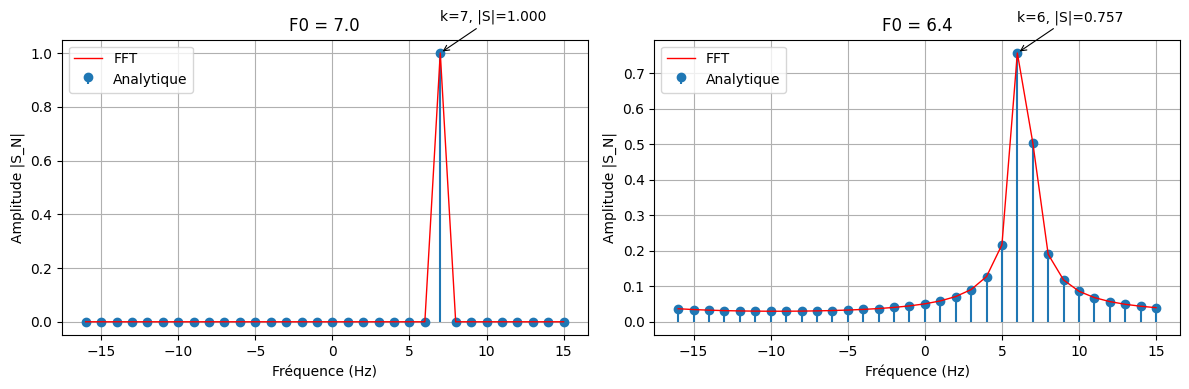

In [10]:

N = 16
a = 1/32
T = 2 * N * a   # = 1
k = np.arange(-N, N)      # -16 .. 15
freqs = k / T             # fréquences en abscisse (ici k)

def S_N_k(F0):
    delta = freqs - F0
    numer = np.sin(2 * np.pi * N * a * delta)
    denom = np.sin(np.pi * a * delta)
    S = np.empty_like(numer, dtype=np.complex128)
    nonzero = np.abs(denom) > 1e-12
    S[nonzero] = a * numer[nonzero] / denom[nonzero]
    S[~nonzero] = a * 2 * N   # limite quand delta -> 0
    return S

def calcul_S_N_TFD(F0):
    """
    Calcule S_N(lambda) en utilisant la FFT centrée
    pour un signal complexe exponentiel x[n] = exp(2iπ F0 n a)

    Paramètres
    ----------
    F0 : float
        Fréquence du signal
    N : int
        Moitié du nombre de points (signal de longueur 2N)
    a : float
        Intervalle d'échantillonnage

    Retourne
    -------
    lambda_k_shifted : np.ndarray
        Axe fréquentiel centré [-1/(2a), 1/(2a)]
    S_N_k_shifted : np.ndarray
        Transformée de Fourier discrète centrée
    """
    n = np.arange(-N, N)
    x = np.exp(2j * np.pi * F0 * a * n)

    x_fft = np.roll(x, N)  # x_fft[m] = x[m-N], m = 0..2N-1

    S = fft(x_fft)

    # Axe fréquentiel décalé de 0 à N-1
    k = np.arange(2*N)
    lambda_k = k / (2*N*a)  # fréquences discrètes

    S *= a * np.exp(2j * np.pi * lambda_k * N * a)

    S_N_k_shifted = fftshift(S)


    return S_N_k_shifted

# Tracé côte à côte pour F0=7 et F0=6.4

F0_list = [7.0, 6.4]
plt.figure(figsize=(12, 4))
for i, F0 in enumerate(F0_list, 1):
    S = S_N_k(F0)
    S_fft = calcul_S_N_TFD(F0)

    plt.subplot(1, 2, i)

    # Tracé analytique
    markerline, stemlines, baseline = plt.stem(freqs, np.abs(S), markerfmt='o', basefmt=' ', label="Analytique")
    plt.setp(markerline, markersize=6)

    # Tracé de la courbe obtenue par FFT (ligne continue)
    plt.plot(freqs, np.abs(S_fft), label="FFT", color='r', linewidth=1)

    # Identifier le pic du spectre
    peak_idx = np.argmax(np.abs(S))
    peak_k = k[peak_idx]
    peak_val = np.abs(S[peak_idx])
    plt.annotate(f"k={int(peak_k)}, |S|={peak_val:.3f}",
                 xy=(peak_k, peak_val), xytext=(peak_k, peak_val * 1.12),
                 arrowprops=dict(arrowstyle="->", linewidth=0.8))

    plt.title(f"F0 = {F0}")
    plt.xlabel("Fréquence (Hz)")
    plt.ylabel("Amplitude |S_N|")
    plt.grid(True)
    plt.legend()

plt.tight_layout()
plt.show()

# **Exercice 2 : Transformée de Fourier à court terme**


### 1. Transformée de Fourier de la Distribution Échantillonnée $\hat{f}_e$ :

Soit $f$ un signal analogique échantillonné avec une période $T_e$ (ici $T_e = 1$ seconde).Le signal échantillonné est modélisé par une distribution (peigne de Dirac pondéré) :

$$
f_e(t) = \sum_{n=0}^{T} f(n T_e) \cdot \delta(t - n)
$$

Nous cherchons la Transformée de Fourier (TF) $\hat{f}_e(\omega)$ définie par :
$$
\hat{f}_e(\omega) = \int_{-\infty}^{+\infty} f_e(t) e^{-2i\pi \omega t} \, dt
$$

Par linéarité de l'intégrale :
$$
\hat{f}_e(\omega) = \sum_{n=0}^{T} f(n) \int_{-\infty}^{+\infty} \delta(t - n) e^{-2i\pi \omega t} \, dt
$$

En utilisant la propriété de tamisage de la distribution de Dirac ($\int \delta(t-t_0)g(t)dt = g(t_0)$), l'intégrale vaut $e^{-2i\pi \omega n T_e}$.

Résultat :

$$\boxed{\hat{f}_e(\omega) = \sum_{n=0}^{T} f(n) e^{-2i\pi n \omega}}$$



On considère le signal $f$ composé de deux sinusoïdes consécutives :$f_1 = 0.1$ Hz pendant $T_1 = 128$ s.$f_2 = 0.2$ Hz pendant $T_2 = 64$ s.La durée totale du signal utile est $T_{total} = 128 + 64 = 192$ secondes (donc 192 échantillons car $T_e=1s$).
Le signal $f(t)$ est défini par :
$
f(t)=
\begin{cases}
\sin(2\pi \cdot 0.1 \, t), & 0 \le t < 128, \\[6pt]
\sin(2\pi \cdot 0.2 \, t), & 128 \le t < 192.
\end{cases}
$

On va compléter ce signal avec des zéros pour atteindre des tailles de $N=256$ et $N=512$, et analyser l'effet sur le spectre.

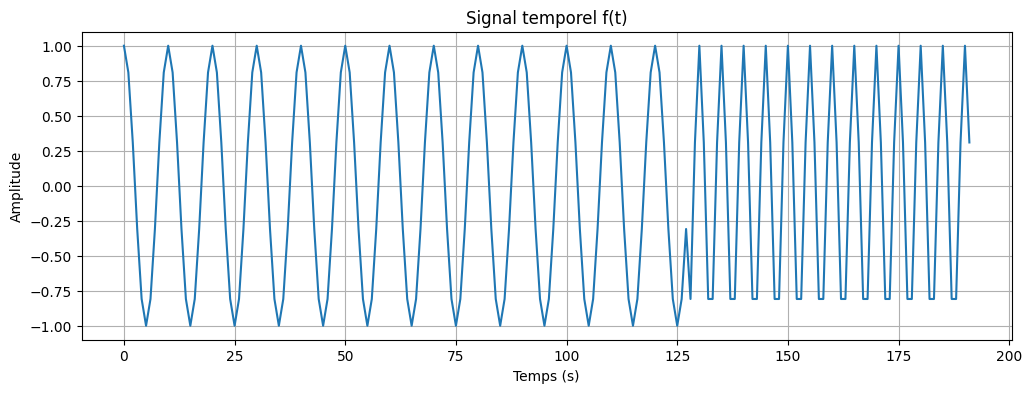

In [11]:
Te = 1.0
Fe = 1.0 / Te

t1 = np.arange(0, 128, Te)
s1 = np.cos(2 * np.pi * 0.1 * t1)


t2 = np.arange(128, 128 + 64, Te)
s2 = np.cos(2 * np.pi * 0.2 * t2)


signal = np.concatenate((s1, s2))


plt.figure(figsize=(12, 4))
plt.plot(np.concatenate((t1, t2)), signal)
plt.title("Signal temporel f(t)")
plt.xlabel("Temps (s)")
plt.ylabel("Amplitude")
plt.grid(True)
plt.show()

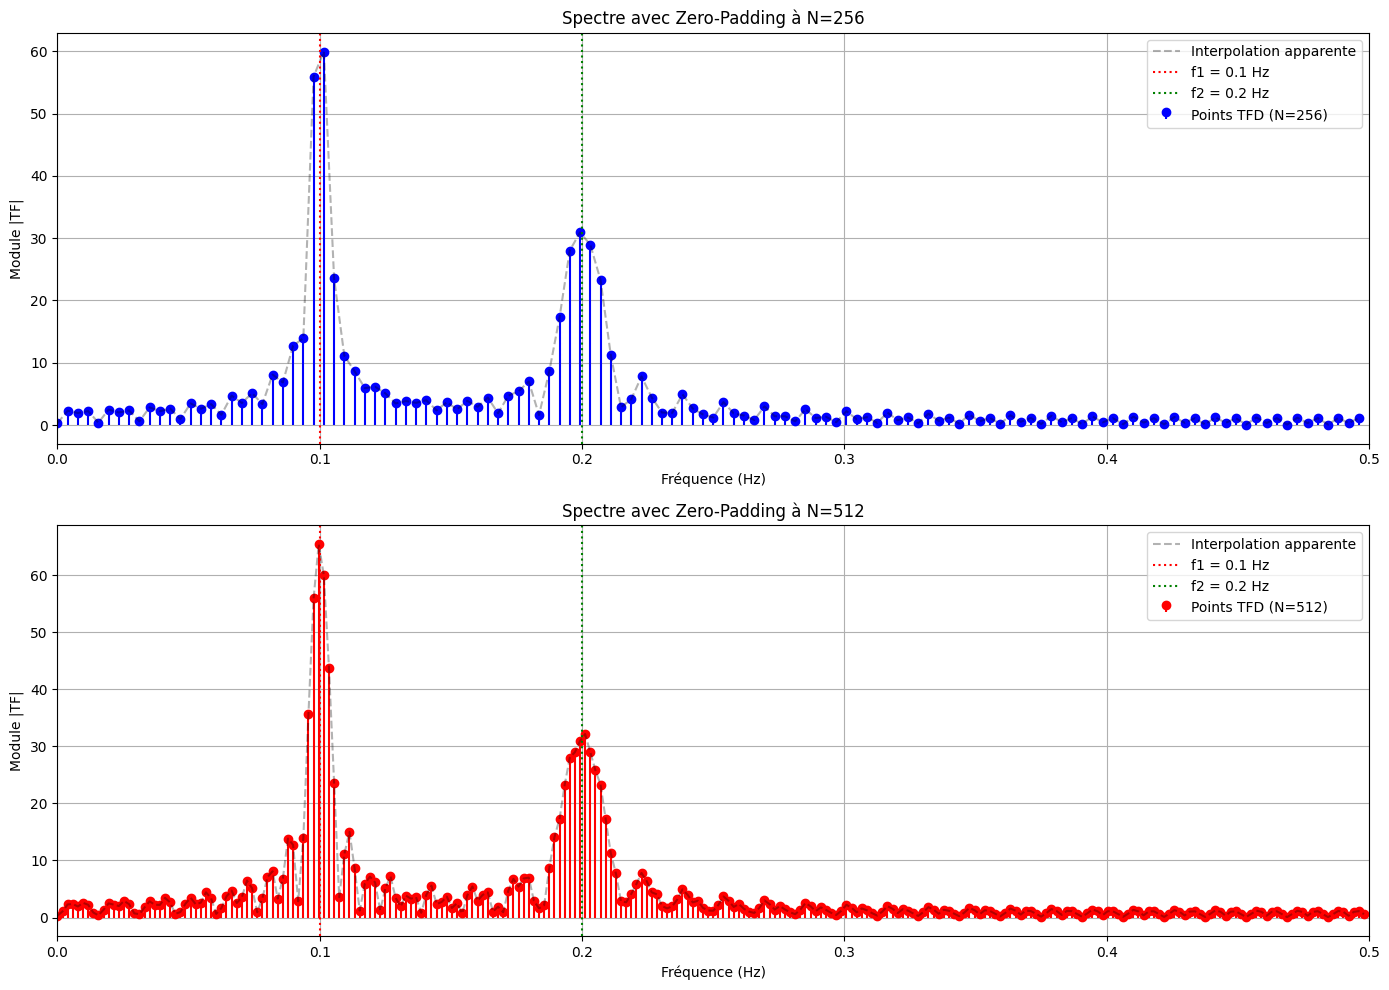

In [12]:
def plot_spectrum_padded(signal, N_fft, color_stem, title):
    spectre = fft(signal, n=N_fft)
    freqs = fftfreq(N_fft, d=Te)
    magnitude = np.abs(spectre)

    mask = freqs >= 0

    plt.stem(freqs[mask], magnitude[mask],
             linefmt=f'{color_stem}-', markerfmt=f'{color_stem}o',
             basefmt=" ", label=f'Points TFD (N={N_fft})')

    plt.plot(freqs[mask], magnitude[mask],
             color='black', alpha=0.3, linestyle='--',
             label='Interpolation apparente')

    plt.title(title)
    plt.xlabel("Fréquence (Hz)")
    plt.ylabel("Module |TF|")
    plt.xlim(0, 0.5)

    plt.axvline(0.1, color='red', linestyle=':', label='f1 = 0.1 Hz')
    plt.axvline(0.2, color='green', linestyle=':', label='f2 = 0.2 Hz')

    plt.legend()
    plt.grid(True)
plt.figure(figsize=(14, 10))

# Cas 1 : N = 256
plt.subplot(2, 1, 1)
plot_spectrum_padded(signal, 256, 'b', "Spectre avec Zero-Padding à N=256")

# Cas 2 : N = 512
plt.subplot(2, 1, 2)
plot_spectrum_padded(signal, 512, 'r', "Spectre avec Zero-Padding à N=512")

plt.tight_layout()
plt.show()

Les fréquences de la FFT sont données par :

- Le pas de fréquence :  
  $\Delta \nu = \dfrac{F_e}{N}$

- Les fréquences des bins :  
  $\nu_k = k\,\Delta \nu = k \dfrac{F_e}{N}$  
  pour $k = 0, 1, 2, \dots, N-1$.

L’ensemble des fréquences est donc :  
$\{\,0,\ \Delta \nu,\ 2\Delta \nu,\ 3\Delta \nu,\ \dots,\ (N-1)\Delta \nu\,\}$

### Exemple pour $N = 256$ :
$\Delta \nu = \dfrac{F_e}{256} = \dfrac{1}{256} \approx 0.0039\ \text{Hz}$

Fréquences :  
$0,\ 0.0039,\ 0.0078,\ \dots$

### Exemple pour $N = 512$ :
$\Delta \nu = \dfrac{F_e}{512} = \dfrac{1}{512} \approx 0.00195\ \text{Hz}$

Le pas de fréquence est alors deux fois plus fin.


### Influence du zero-padding sur la résolution fréquentielle de la TFD :
Le zero-padding consiste à augmenter artificiellement la longueur de la FFT en ajoutant des zéros au signal. Si la FFT est calculée sur $N$ points, le pas fréquentiel est
$\Delta \nu = \dfrac{F_e}{N}$.
En augmentant $N$ grâce au zero-padding, on diminue $\Delta \nu$, ce qui crée un maillage fréquentiel plus fin. Le spectre apparaît donc plus détaillé car les fréquences disponibles deviennent
$0,\ \Delta \nu,\ 2\Delta \nu,\ \dots,\ (N-1)\Delta \nu$.

Cependant, la résolution spectrale réelle ne dépend pas du zero-padding mais de la durée réelle du signal $T$. Elle vaut
$\dfrac{1}{T}$.

Le zero-padding n’augmente donc pas la capacité à séparer deux fréquences proches ; il n’interpole que le spectre sans ajouter d’information physique.


### 2. Analyse avec Fenêtre Rectangulaire :

Cette partie introduit la notion d'analyse spectrale localisée dans le temps, définie par la formule :

$$
F(n, \omega) = \sum_{k=-M}^{M-1} f(n-k) g(k) e^{-i 2\pi k \omega}
$$

où $g(k)$ est une fenêtre rectangulaire de durée $2M$ ($M$ est la demi-taille).

**1. Expliquer en quoi la terminologie "court terme" est appropriée.**
Contrairement à la TFD classique qui intègre le signal de $-\infty$ à $+\infty$ (ou sur toute sa durée $T$), cette transformée utilise une fenêtre $g(k)$ de support fini $[-M, M-1]$. Elle ne "voit" le signal que sur une courte durée $2M$ autour de l'instant $n$. Cela permet de localiser les fréquences temporellement.

**2. Lien avec la TFD et changement d'indice.**
On veut évaluer $F$ à la fréquence $\omega_m = \frac{m}{2M}$.
$F(n, \frac{m}{2M}) = \sum_{k=-M}^{M-1} \left[ f(n-k)g(k) \right] e^{-2i\pi k \frac{m}{2M}}$

$
on pose j = k + M
$

$$
F\left(n, \frac{m}{2M}\right)
= \sum_{j=0}^{2M-1} f(n-(j-M))\, g(j-M)\, e^{-i 2\pi (j-M)\frac{m}{2M}} \\
= \sum_{j=0}^{2M-1} f(n-(j-M))\, g(j-M)\, e^{-i 2\pi j\frac{m}{2M}}\, e^{\,i\pi m} \\
= (-1)^m \sum_{j=0}^{2M-1} f(n-(j-M))\, g(j-M)\, e^{-i 2\pi j\frac{m}{2M}} \\
$$

Posons : $ h_j = f(n-(j-M)) g(j-M) $ On a alors :

$$ F\left(n, \frac{m}{2M}\right) = (-1)^m \sum_{j=0}^{2M-1} h_j \, e^{-i 2\pi j\frac{m}{2M}} $$

Il suffit donc de construire h (à partir de f et g), appliquer une FFT de longueur 2M et multiplier par la phase $(−1)^m$

**3. TFDs des convolutions :**

Pour $n$ fixé, on a le calcul de $F(n, \omega_m)$ se ramène à une TFD. La fenêtre $g(k)$ a une taille de support de $2M$. Par conséquent, la TFD calculée sur cette fenêtre génère un vecteur de $2M$ points de fréquence. Pour un $n$ donné, on obtient un vecteur:$$V_n = \left[ F(n, \omega_0), F(n, \omega_1), \dots, F(n, \omega_{2M-1}) \right]$$Ce vecteur a une dimension de $1 \times 2M$.2.

$n$ varie dans l'ensemble $\{0, 1, \dots, T\}$. Le nombre total d'instants considérés est donc :$$\text{Nombre d'instants} = T + 1$$

Lignes : correspond à un instant $n$. Il y a $T+1$ lignes.
Colonnes : Chaque colonne correspond à une fréquence $\omega_m$. Il y a $2M$ colonnes.

La matrice $\mathbf{S}$ s'écrit :$$\mathbf{S} =
\begin{pmatrix}
F(0, \omega_0) & F(0, \omega_1) & \cdots & F(0, \omega_{2M-1}) \\
F(1, \omega_0) & F(1, \omega_1) & \cdots & F(1, \omega_{2M-1}) \\
\vdots & \vdots & \ddots & \vdots \\
F(T, \omega_0) & F(T, \omega_1) & \cdots & F(T, \omega_{2M-1})
\end{pmatrix}$$

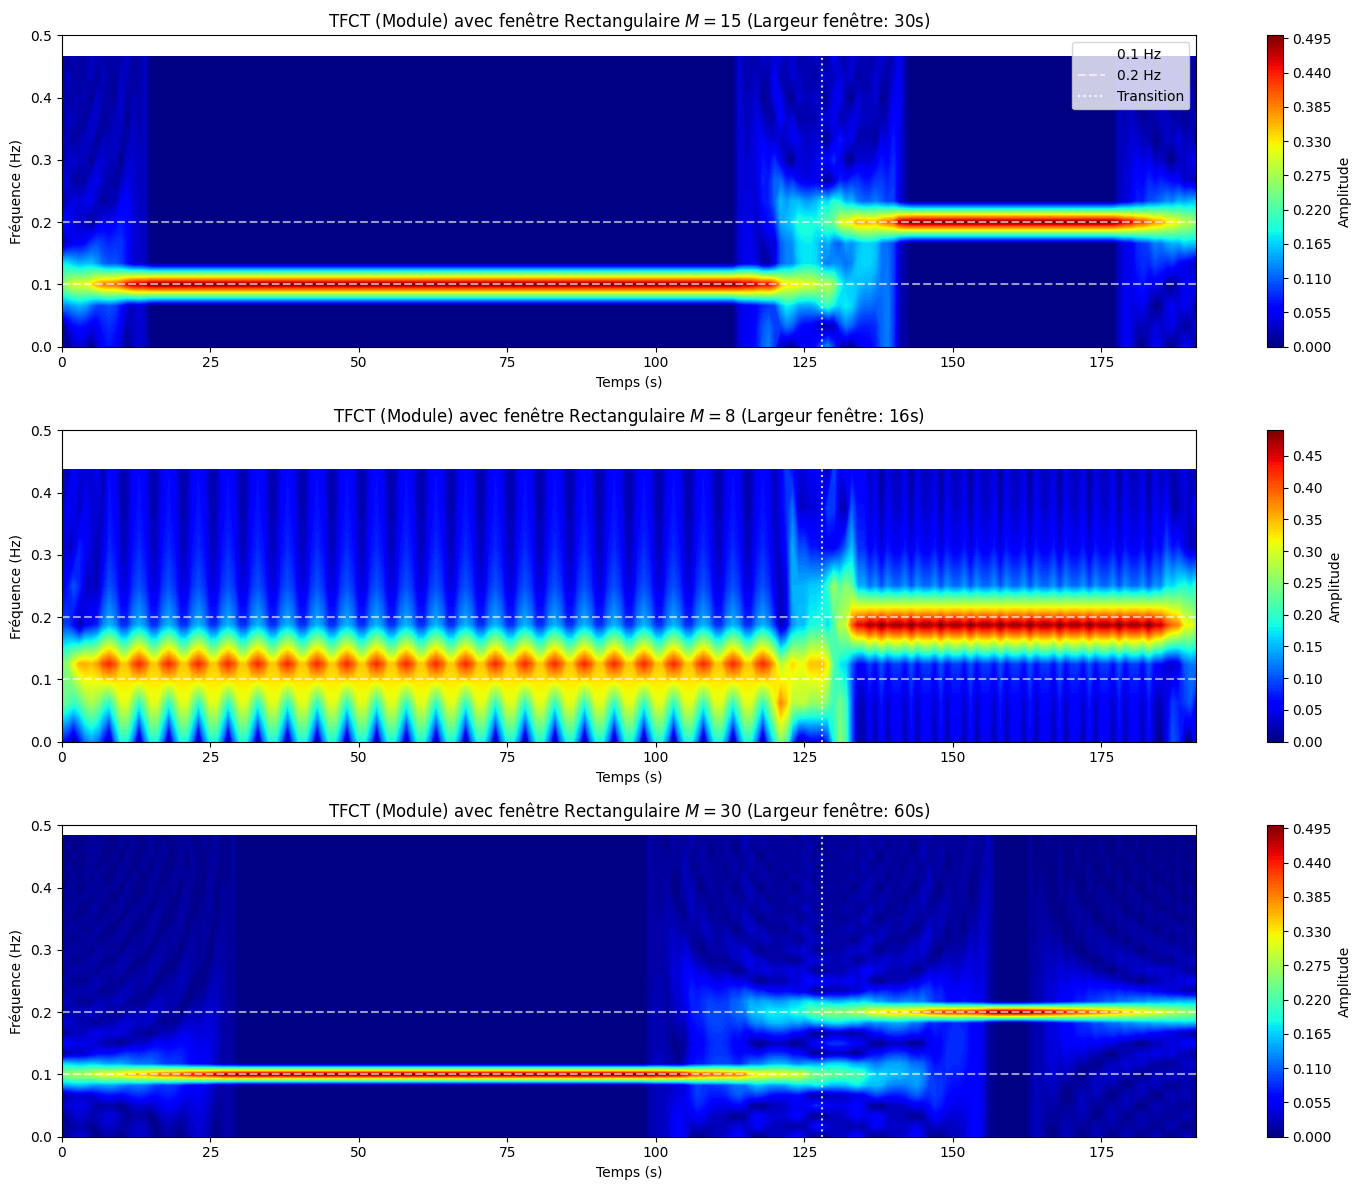

In [13]:
def compute_stft_rect(signal, M):
    N_signal = len(signal)
    win_len = 2 * M
    signal_pad = np.pad(signal, (M, M), mode='constant')
    fenetre = np.ones(win_len) / win_len

    S = []

    # Boucle sur le temps n (de 0 à T)
    for n in range(N_signal):
        # Extraction du segment local [n-M, n+M-1]
        # Dans le signal paddé, cela correspond aux indices [n, n + 2M]
        segment = signal_pad[n : n + win_len]

        # TFD du segment fenêtré
        # On prend le module directement pour l'affichage
        spectrum = np.abs(np.fft.fft(segment * fenetre))
        S.append(spectrum)

    return np.array(S)

M_values = [15, 8, 30]

plt.figure(figsize=(15, 12))

for i, M in enumerate(M_values):
    S = compute_stft_rect(signal, M)
    # Temps : de 0 à T (secondes)
    time_axis = np.arange(S.shape[0])

    freq_axis = np.fft.fftfreq(2*M, d=Te)
    freq_axis_shifted = np.fft.fftshift(freq_axis) # pour centrer autour de 0

    S_shifted = np.fft.fftshift(S, axes=1) # coherent avec freq centrées

    mask_pos = freq_axis_shifted >= 0
    freq_axis_plot = freq_axis_shifted[mask_pos]
    S_plot = S_shifted[:, mask_pos] # que les freq pos

    # meshgrid inputs : (X, Y) X=Temps, Y=Fréquence
    X, Y = np.meshgrid(time_axis, freq_axis_plot)

    # Contourf attend Z de forme (len(Y), len(X)), donc on transpose S_plot
    Z = S_plot.T

    ax = plt.subplot(3, 1, i+1)
    c = ax.contourf(X, Y, Z, 100, cmap='jet') # 100 niveaux : lisse
    plt.colorbar(c, label='Amplitude')

    ax.set_title(f'TFCT (Module) avec fenêtre Rectangulaire $M={M}$ (Largeur fenêtre: {2*M}s)')
    ax.set_xlabel('Temps (s)')
    ax.set_ylabel('Fréquence (Hz)')
    ax.set_ylim(0, 0.5)

    # Lignes repères
    ax.axhline(0.1, color='white', linestyle='--', alpha=0.6, label='0.1 Hz')
    ax.axhline(0.2, color='white', linestyle='--', alpha=0.6, label='0.2 Hz')
    ax.axvline(128, color='white', linestyle=':', alpha=0.8, label='Transition')
    if i == 0: ax.legend()

plt.tight_layout()
plt.show()

$M = 8$ (Fenêtre courte : 16 sec)

Temps : La transition à $t=128s$ est assez nette (verticale). On localise bien le moment du changement.

Fréquence : Les bandes rouges sont très larges, floues.

La résolution fréquentielle est mauvaise ($\Delta f \approx 1/16 = 0.06$ Hz), ce qui rend difficile la distinction précise de la fréquence exacte.

$M = 30$ (Fenêtre longue : 60 sec)

Fréquence : Les bandes rouges sont très fines. La résolution fréquentielle est excellente, on distingue très précisément 0.1 Hz et 0.2 Hz.

Temps : La transition est très floue. Autour de 128s, le changement de fréquence semble s'étaler sur une longue période. On perd la précision temporelle.

$M = 15$ (Compromis) : Offre un équilibre intermédiaire entre la précision temporelle et la précision fréquentielle.

## 3. Analyse avec la Fenêtre Gaussienne :

### Calcul de $\sigma$ pour la fenêtre gaussienne avec $T=192$ :

Pour que la fenêtre gaussienne reste significative aux bords de la fenêtre, on impose :

$$
g(\pm M) \ge 10^{-3}
$$

La fenêtre gaussienne est définie par :

$$
g(k) = e^{- \pi \frac{k^2}{T^2 \sigma^2}}
$$

En prenant $k = M$, on a donc :

$$
e^{- \pi \frac{M^2}{T^2 \sigma^2}} = 10^{-3}
$$

### Étapes de calcul :

1. Prendre le logarithme naturel des deux côtés :

$$
- \pi \frac{M^2}{T^2 \sigma^2} = \ln(10^{-3}) = -3 \ln(10)
$$

2. Isoler $\sigma^2$ :

$$
\sigma^2 = \frac{\pi M^2}{3 \ln(10) \, T^2} \quad \Rightarrow \quad \sigma = \frac{M}{T} \sqrt{\frac{\pi}{3 \ln(10)}}
$$

### Valeurs numériques pour $T = 192$ :

On a :

$$
\sqrt{\frac{\pi}{3 \ln(10)}} \approx 0.607
$$

Donc :

$$
\sigma \approx 0.607 \cdot \frac{M}{192}
$$

### Valeurs numériques pour $T = 192$ :

| $M$   | $\sigma$ approximatif | Interprétation numérique |
|-------|----------------------|-------------------------|
| 15    | 0.0475               | Fenêtre très étroite : **bonne résolution temporelle**, faible résolution fréquentielle |
| 30    | 0.095                | Fenêtre plus large : **compromis temps-fréquence** |
| 60    | 0.190                | Fenêtre très large : **bonne résolution fréquentielle**, moins précise en temps |

### Interprétation concrète :

- **Plus $M$ est petit** → fenêtre étroite → détection précise des changements de fréquence (0.1 Hz → 0.2 Hz)  
- **Plus $M$ est grand** → fenêtre large → meilleure précision en fréquence, mais la transition temporelle devient floue  
- La constante $0.607$ montre que $\sigma$ est **beaucoup plus petit que la durée totale**, ce qui assure que la fenêtre est bien **localisée autour du centre du segment**.  
- Les valeurs de $\sigma$ (0.0475 à 0.19) sont donc normales pour une STFT localisée, permettant de **visualiser les variations temporelles tout en conservant un spectre fréquentiel correct**.

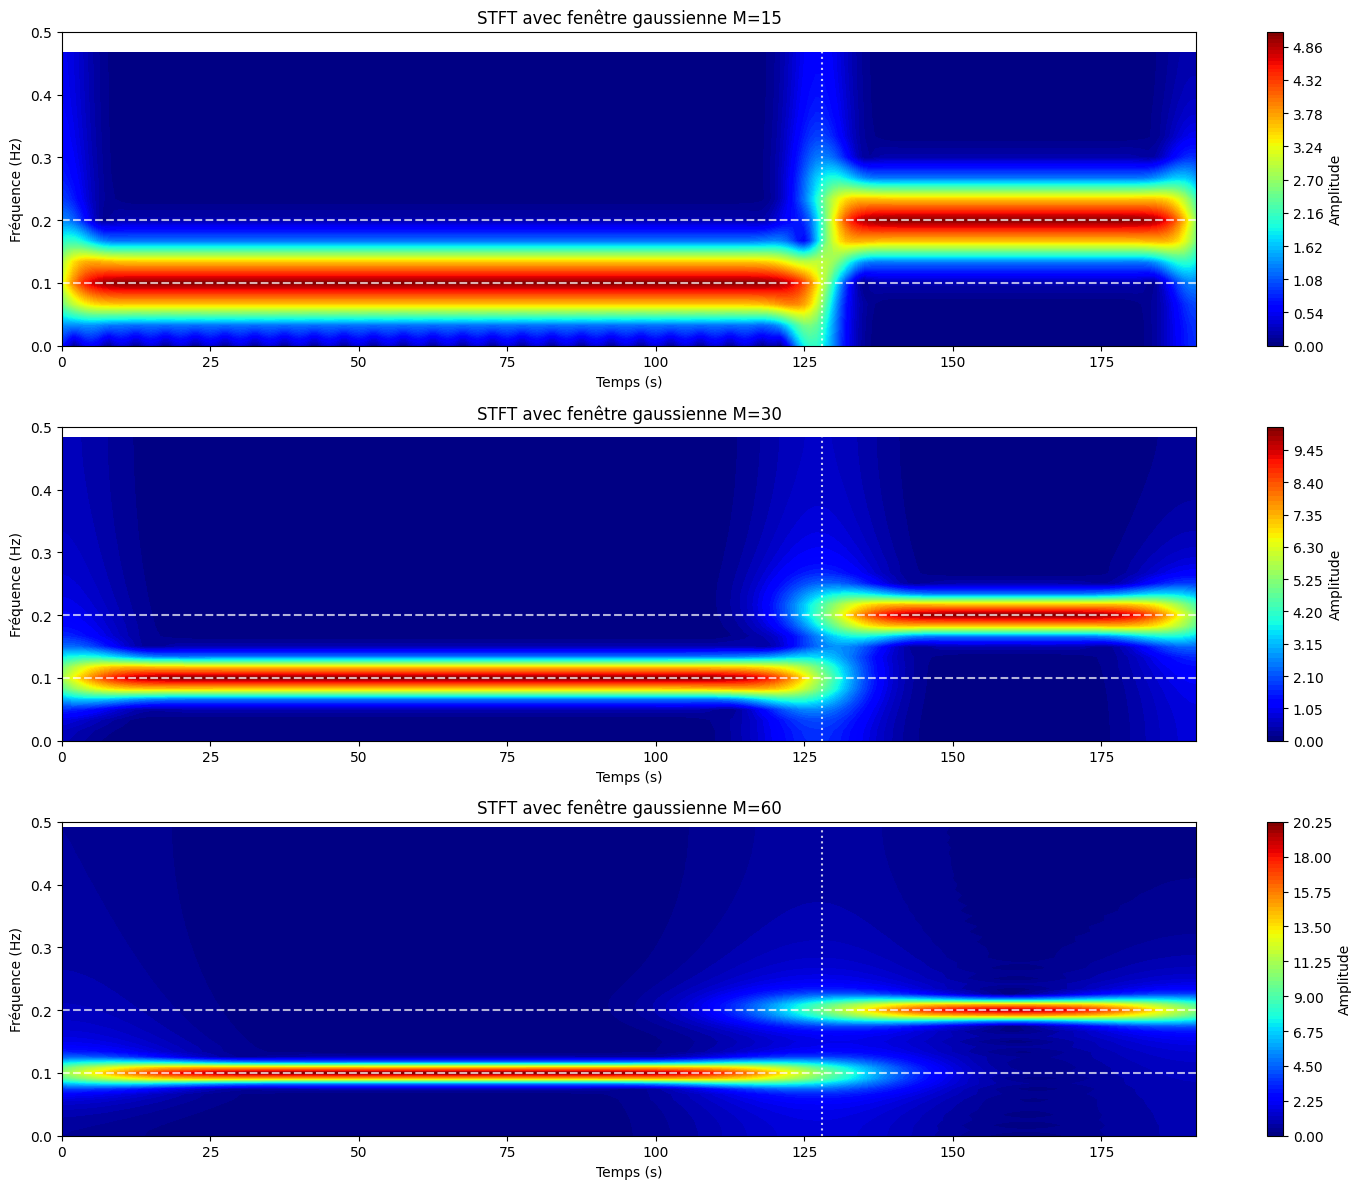

In [14]:
# Fonction pour générer la fenêtre gaussienne avec pi et T
def gaussian_window(M, T=192):
    sigma = (M / T) * np.sqrt(np.pi / (3 * np.log(10)))
    k = np.arange(-M, M)
    g = np.exp(-np.pi * k**2 / (T**2 * sigma**2))
    return g

# Fonction pour calculer la STFT avec une fenêtre gaussienne
def compute_stft_gaussian(signal, g):
    N_signal = len(signal)
    M = len(g) // 2
    signal_pad = np.pad(signal, (M, M), mode='constant')
    S = []
    for n in range(N_signal):
        segment = signal_pad[n : n + len(g)]
        spectrum = np.fft.fft(segment * g)
        S.append(np.abs(spectrum))
    return np.array(S)

# Définition des fenêtres g1, g2, g3
M_values = [15, 30, 60]
windows = [gaussian_window(M) for M in M_values]

# Calcul STFT pour chaque fenêtre
STFT_results = [compute_stft_gaussian(signal, g) for g in windows]

# Tracé
plt.figure(figsize=(15, 12))
for i, S in enumerate(STFT_results):
    M = M_values[i]
    time_axis = np.arange(S.shape[0])
    freq_axis = np.fft.fftfreq(2*M, d=Te)
    freq_axis_shifted = np.fft.fftshift(freq_axis)
    S_shifted = np.fft.fftshift(S, axes=1)

    # On ne prend que les fréquences positives
    mask_pos = freq_axis_shifted >= 0
    freq_axis_plot = freq_axis_shifted[mask_pos]
    S_plot = S_shifted[:, mask_pos].T

    X, Y = np.meshgrid(time_axis, freq_axis_plot)
    ax = plt.subplot(3,1,i+1)
    c = ax.contourf(X, Y, S_plot, 100, cmap='jet')
    plt.colorbar(c, ax=ax, label='Amplitude')

    ax.set_title(f'STFT avec fenêtre gaussienne M={M}')
    ax.set_xlabel('Temps (s)')
    ax.set_ylabel('Fréquence (Hz)')
    ax.set_ylim(0, 0.5)
    ax.axhline(0.1, color='white', linestyle='--', alpha=0.7)
    ax.axhline(0.2, color='white', linestyle='--', alpha=0.7)
    ax.axvline(128, color='white', linestyle=':', alpha=0.8)

plt.tight_layout()
plt.show()

### Analyse des résultats :

**Fenêtre petite ($M=15$, $g_1$) :**

- Bonne résolution temporelle : transition $0.1 \, \text{Hz} \to 0.2 \, \text{Hz}$ visible
- Spectre fréquentiel plus flou (pics moins nets)

**Fenêtre moyenne ($M=30$, $g_2$) :**

- Bon compromis temps-fréquence
- Transition encore visible, fréquence plus précise

**Fenêtre grande ($M=60$, $g_3$) :**

- Très bonne résolution fréquentielle : pics nets à $0.1 \, \text{Hz}$ et $0.2 \, \text{Hz}$
- Moins bonne localisation temporelle : transition étalée
